In [1]:
import sys
from pathlib import Path

parent = Path.cwd().parent
sys.path.append(str(parent))

In [2]:
from src.integrator import ComplexIntegrator
from src.integrand_builder import ContextManager, spherical
import oneloop_bridge
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# do this to trigger the banner here so it doesn't get in the way later
oneloop_bridge.set_renormalization_scale(1.0)

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

In [3]:
cm = ContextManager(force_rebuild = True) 

Compiling evaluator: "combined_result"
Done!


In [4]:
import symbolica


def get_integrals(masses, n_epochs, spe):
    unsub_res = []
    sub_res = []
    
    rng = symbolica.RandomNumberGenerator(0, 0)
    
    for m in tqdm(masses):
        cm.masses = [m,m,m]

        ci3 = ComplexIntegrator(3)
        cm.a = 1
        cm.b = 0
        cm.c = 0
        unsub_int = ci3.integrate(cm.eval, spherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        ci2 = ComplexIntegrator(3)
        cm.a = 1
        cm.b = 1
        cm.c = 1
        sub_int = ci2.integrate(cm.eval, spherical,n_epochs=n_epochs, samples_per_epoch=spe, rng=rng)

        unsub_res.append(unsub_int)
        sub_res.append(sub_int)
    return unsub_res, sub_res

def get_reference(masses):
    baseline = []
    for m in masses:
        cm.masses = [m,m,m]
        baseline.append(cm.get_reference())
    return baseline


In [5]:
def plot_convergence(xs, unsub_res, sub_res):
    plt.scatter(xs, [r.convergence() for r in unsub_res], label = 'without counterterm')
    plt.scatter(xs, [r.convergence() for r in sub_res], label = 'with counterterm')

    plt.ylabel('convergence')
    plt.legend()

In [6]:
def plot_real_result(xs, unsub_res, sub_res, reference_xs, reference):
    plt.plot(reference_xs, [r.real for r in reference], label = 'OneLOop')
    plt.scatter(xs, [r.real_avg for r in unsub_res], label = 'without counterterm')
    plt.scatter(xs, [r.real_avg for r in sub_res], label = 'with counterterm')
    plt.legend()

def plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference):
    plt.plot(reference_xs, [r.imag for r in reference], label = 'OneLOop')
    plt.scatter(xs, [r.imag_avg for r in unsub_res], label = 'without counterterm')
    plt.scatter(xs, [r.imag_avg for r in sub_res], label = 'with counterterm')
    plt.legend()

In [7]:
masses = [0.5 - 1j*0.75** i for i in range(3,23)]
unsub_res, sub_res = get_integrals(masses,n_epochs=100, spe = 100)
ref_masses = [0.5 - 1j*0.75** i for i in list(np.linspace(3,23,200))]
reference = get_reference(ref_masses)

100%|██████████| 20/20 [00:09<00:00,  2.10it/s]


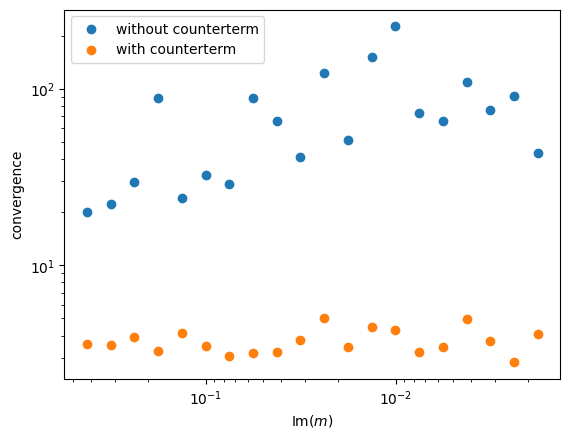

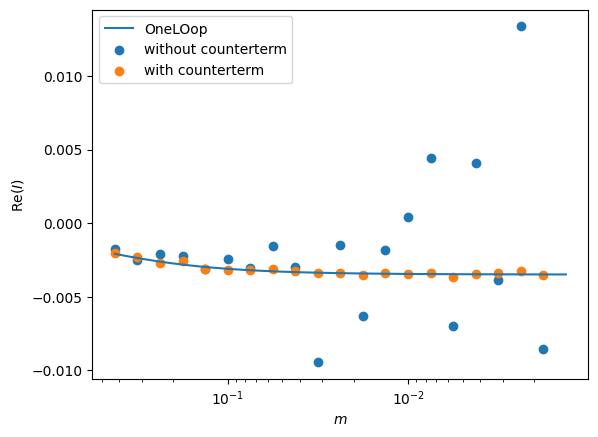

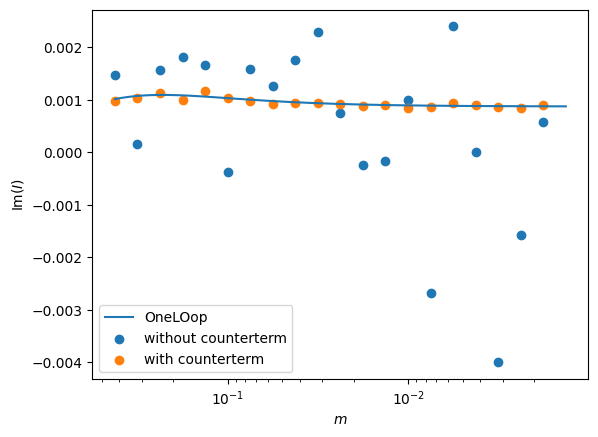

In [8]:
xs = [-m.imag for m in masses]
reference_xs = [-m.imag for m in ref_masses]
plt.show()
plot_convergence(xs, unsub_res, sub_res)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Im($m$)')
plt.gca().invert_xaxis()
plt.show()

plot_real_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xscale('log')
plt.xlabel('$m$')
plt.ylabel('Re($I$)')
plt.gca().invert_xaxis()
plt.show()

plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xscale('log')
plt.xlabel('$m$')
plt.ylabel('Im($I$)')
plt.gca().invert_xaxis()
plt.show()

In [9]:
masses = list(np.linspace(3.499**0.5,3.501**0.5,20))
unsub_res, sub_res = get_integrals(masses,n_epochs=100, spe = 500)
ref_masses = list(np.linspace(3.499**0.5,3.501**0.5,200))
reference = get_reference(ref_masses)

100%|██████████| 20/20 [00:43<00:00,  2.18s/it]


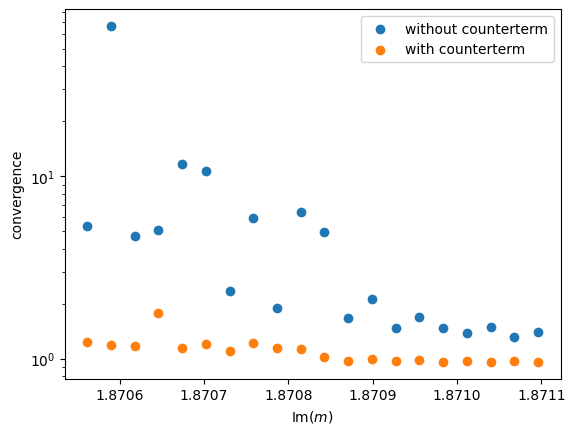

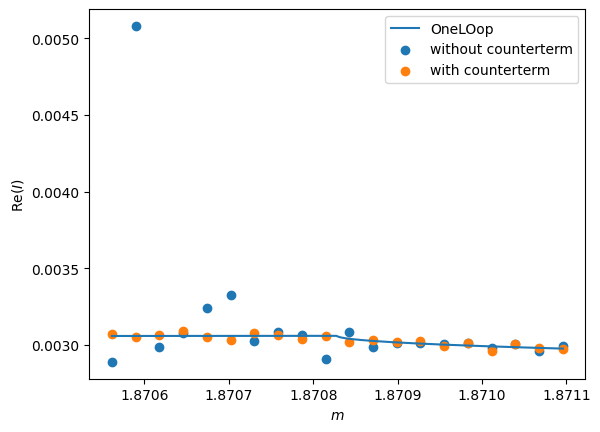

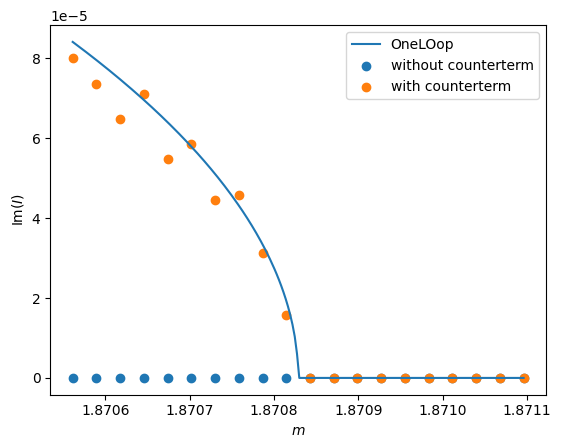

In [10]:
xs = masses
reference_xs = ref_masses
plt.show()
plot_convergence(xs, unsub_res, sub_res)
plt.yscale('log')
plt.xlabel('Im($m$)')
plt.show()

plot_real_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('$m$')
plt.ylabel('Re($I$)')
plt.show()

plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('$m$')
plt.ylabel('Im($I$)')
plt.show()

# set the center such that the origin is not inside the origin

In [11]:
cm.origin = np.array([0,2,0,0])
cm.m = 0.5
cm.get_threshold_report()

q = [-1.  -0.5  0.   0. ]
q² = 0.75
E-surface value at origin = 2.8603513883531875
q = [-1.   0.  -0.5  0. ]
q² = 0.75
E-surface value at origin = 3.6544427965902777
q = [-2.  -0.5 -0.5  0. ]
q² = 3.5
E-surface value at origin = 1.0372034736909352


In [12]:
masses = list(np.linspace(0.4,2.1,20))
unsub_res, sub_res = get_integrals(masses,n_epochs=100, spe = 100)
ref_masses = list(np.linspace(0.4,2.1,200))
reference = get_reference(ref_masses)

100%|██████████| 20/20 [00:09<00:00,  2.16it/s]


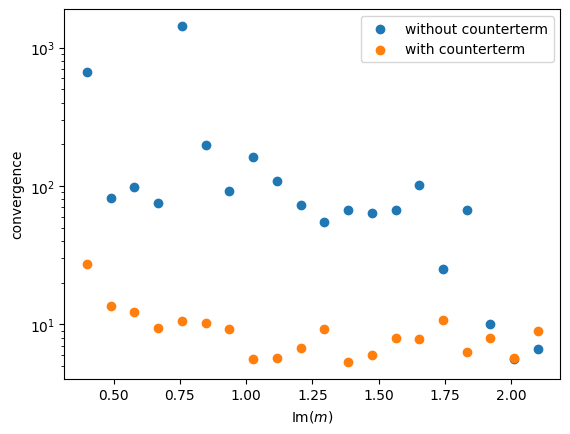

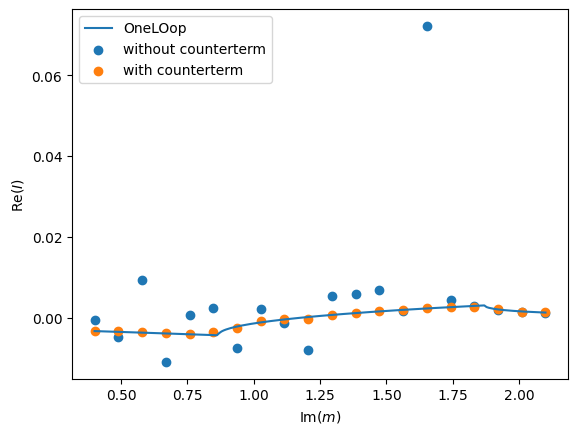

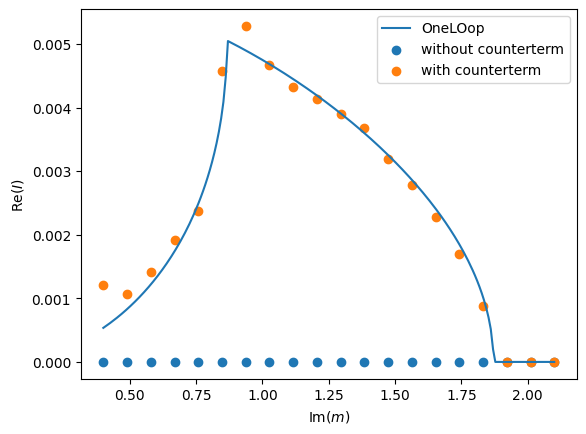

In [13]:
xs = masses
reference_xs = ref_masses
plt.show()
plot_convergence(xs, unsub_res, sub_res)
plt.yscale('log')
plt.xlabel('Im($m$)')
plt.show()

plot_real_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('Im($m$)')
plt.ylabel('Re($I$)')
plt.show()

plot_imag_result(xs, unsub_res, sub_res, reference_xs, reference)
plt.xlabel('Im($m$)')
plt.ylabel('Re($I$)')
plt.show()